In [1]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data overview

## 1, taxonomy.csv

In [2]:
df_taxonomy = pd.read_csv('../dataset/taxonomy.csv')

In [3]:
# Get the count of each unique animal type
type_counts = df_taxonomy['class_name'].value_counts() 
type_percentages = df_taxonomy['class_name'].value_counts(normalize=True) * 100

collection_summary = pd.DataFrame({
    'Count': type_counts,
    'Percentage (%)': type_percentages.round(2)
})
print("Counts per animal type:")
print(collection_summary)

print(f"\nTotal number: {df_taxonomy.shape[0] }")

# Get the total number of unique categories
total_unique_types = df_taxonomy['class_name'].nunique()
print(f"\nTotal number of unique types: {total_unique_types}")

Counts per animal type:
            Count  Percentage (%)
class_name                       
Aves          162           69.23
Amphibia       35           14.96
Insecta        28           11.97
Mammalia        8            3.42
Reptilia        1            0.43

Total number: 234

Total number of unique types: 5


## 2, train.csv

In [4]:
df_train = pd.read_csv('../dataset/train.csv')

### Collection

In [5]:
collection_counts = df_train['collection'].value_counts()

# 2. Calculate the percentage relative to the total number of entries
collection_percentages = df_train['collection'].value_counts(normalize=True) * 100

# 3. Combine into a summary DataFrame
collection_summary = pd.DataFrame({
    'Count': collection_counts,
    'Percentage (%)': collection_percentages.round(2)
})

print("Training Samples by Collection Source:")
print(collection_summary)

Training Samples by Collection Source:
            Count  Percentage (%)
collection                       
XC          23043           64.82
iNat        12506           35.18


### Species distribution

In [6]:
df_train['secondary_labels'] = df_train['secondary_labels'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else []
)

# Count rows where the secondary_labels list is not empty
rows_with_secondary = df_train[df_train['secondary_labels'].map(len) > 0]
secondary_count = len(rows_with_secondary)

print(f"Number of rows with secondary species: {secondary_count}")
print(f"Percentage of total recordings: {((secondary_count / len(df_train)) * 100):.2f}%")

# This combines the primary_label and the secondary_labels list
def combine_labels(row):
    all_labels = [row['primary_label']] + row['secondary_labels']
    return list(set(all_labels))  # set() ensures we don't double-count the same species in one row

df_train['all_species'] = df_train.apply(combine_labels, axis=1)

# Explode the list so each species appearance gets its own row, then count
species_counts = df_train.explode('all_species')['all_species'].value_counts()

print("\n\n Top 5 + Bot 5 Species Appearances (Primary + Secondary):")
print(species_counts.head())
print(species_counts.tail())


Number of rows with secondary species: 4372
Percentage of total recordings: 12.30%


 Top 5 + Bot 5 Species Appearances (Primary + Secondary):
all_species
grekis     1105
whtdov      957
saffin      662
trokin      654
soulap1     650
Name: count, dtype: int64
all_species
70711     2
116570    1
23150     1
23724     1
516975    1
Name: count, dtype: int64


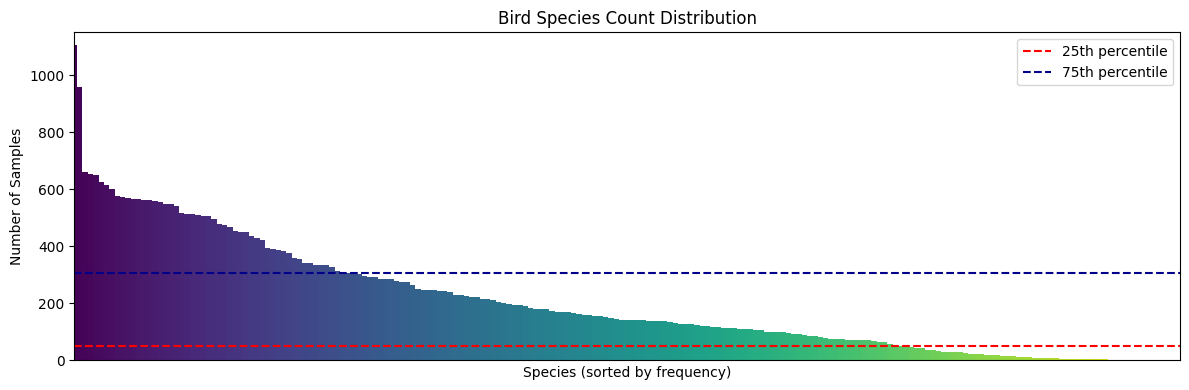

In [7]:
counts = species_counts.sort_values(ascending=False).values
species_indices = np.arange(len(counts))

# Calculate Percentiles for the dashed lines
p25 = np.percentile(counts, 25)
p75 = np.percentile(counts, 75)

# Create the Visualization
plt.figure(figsize=(12, 4))
colors = sns.color_palette("viridis", len(counts))

# Plot the bar chart
plt.bar(species_indices, counts, color=colors, width=1.0, edgecolor='none')

# Add the 25th and 75th percentile lines as seen in Figure 1 of the paper
plt.axhline(y=p25, color='red', linestyle='--', label='25th percentile')
plt.axhline(y=p75, color='darkblue', linestyle='--', label='75th percentile')

# Formatting to match the provided image [cite: 126]
plt.title('Bird Species Count Distribution')
plt.ylabel('Number of Samples')
plt.xlabel('Species (sorted by frequency)')
plt.xlim(0, len(counts))
plt.ylim(0, 1150)
plt.xticks([]) # Hide x-axis labels as there are 206 species
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
def count_undersampled_species(counts_series, threshold=10):
    """
    Counts how many species have total appearances below the given threshold.
    
    Args:
        counts_series (pd.Series): The frequency counts for each species.
        threshold (int): The cutoff for being considered 'undersampled'.
        
    Returns:
        int: Total number of species below the threshold.
    """
    rare_species = counts_series[counts_series < threshold]
    
    return len(rare_species)

print(f"Number of species has less than 10 count: {count_undersampled_species(species_counts, 10)} ")
print(f"Number of species has less than  5 count: {count_undersampled_species(species_counts, 5)} ")

Number of species has less than 10 count: 25 
Number of species has less than  5 count: 14 


In [9]:
species_counts_df = species_counts.reset_index()
species_counts_df.columns = ['species', 'count']

species_counts_df = species_counts_df.merge(
    df_taxonomy[['primary_label', 'class_name']], 
    left_on='species', 
    right_on='primary_label', 
    how='left'
)

species_counts_df = species_counts_df.drop(columns=['primary_label'])
species_counts_df.to_csv('train_species_counts.csv', index=False)

print(f"Number of species in trained dataset: {len(species_counts_df)} ")
print("The file 'train_species_counts.csv' has been created successfully.")

Number of species in trained dataset: 206 
The file 'train_species_counts.csv' has been created successfully.


In [10]:
# There are 234 species to classify, but in train dataset only 206
# missing 28 species sound
missing_species_df = df_taxonomy[~df_taxonomy['primary_label'].isin(species_counts_df['species'])]

# 2. Save these specific rows to a CSV file
missing_species_df.to_csv('missing_species_in_train.csv', index=False)
print("The file 'missing_species_in_train.csv' has been created successfully.")

The file 'missing_species_in_train.csv' has been created successfully.


## 3, train_soundscapes_labels.csv

In [11]:
df_train_soundscapes = pd.read_csv('../dataset/train_soundscapes_labels.csv')

### filename

In [12]:
# Get the total number of unique soundscape files
unique_filenames_count = df_train_soundscapes['filename'].nunique()

print(f"Number of unique soundscape files: {unique_filenames_count}/10658")

Number of unique soundscape files: 66/10658


### primary_label

In [13]:
df_train_soundscapes['label_list'] = df_train_soundscapes['primary_label'].fillna('').str.split(';')

# Explode the list to have one row per species per segment
exploded_soundscapes = df_train_soundscapes.explode('label_list')

# Get counts of occurrences across all soundscape segments
soundscape_species_counts = exploded_soundscapes['label_list'].value_counts()

print("Top 5 + Bot 5 species occurrences in soundscapes:")
print(soundscape_species_counts.head(5))
print(soundscape_species_counts.tail(5))

Top 5 + Bot 5 species occurrences in soundscapes:
label_list
65380     666
517063    626
22973     426
555146    420
23158     350
Name: count, dtype: int64
label_list
rutjac1    2
plcjay1    2
wfwduc1    2
sibtan2    2
ruther1    2
Name: count, dtype: int64


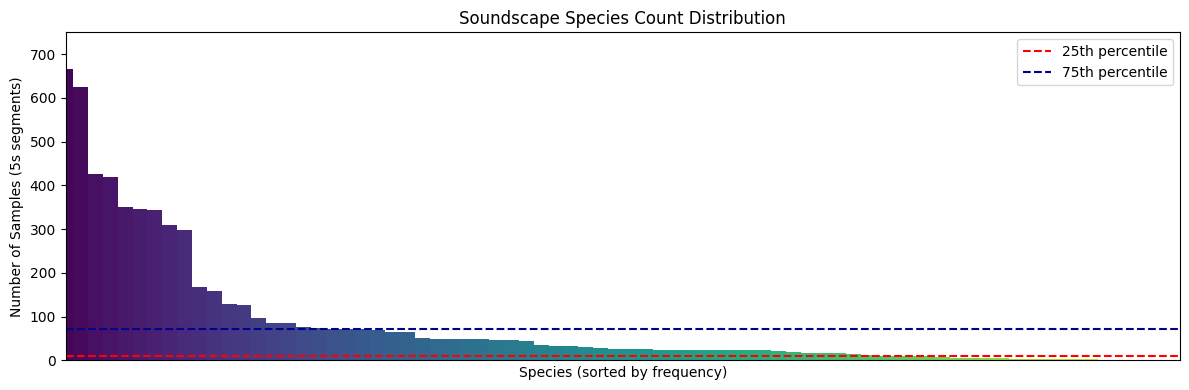

In [14]:
counts = soundscape_species_counts.sort_values(ascending=False).values
species_indices = np.arange(len(counts))

# Calculate Percentiles for the dashed lines
p25 = np.percentile(counts, 25)
p75 = np.percentile(counts, 75)

# 4. Create the Visualization
plt.figure(figsize=(12, 4))
colors = sns.color_palette("viridis", len(counts))

# Plot the bar chart
plt.bar(species_indices, counts, color=colors, width=1.0, edgecolor='none')

# Add the 25th and 75th percentile lines
plt.axhline(y=p25, color='red', linestyle='--', label='25th percentile')
plt.axhline(y=p75, color='darkblue', linestyle='--', label='75th percentile')

# Formatting to match requested style
plt.title('Soundscape Species Count Distribution')
plt.ylabel('Number of Samples (5s segments)')
plt.xlabel('Species (sorted by frequency)')
plt.xlim(0, len(counts))
plt.ylim(0, 750)  # Truncates top species for better tail visibility
plt.xticks([]) 
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
print(f"Number of species has less than 10 count: {count_undersampled_species(soundscape_species_counts, 10)} ")
print(f"Number of species has less than  5 count: {count_undersampled_species(soundscape_species_counts, 5)} ")

Number of species has less than 10 count: 16 
Number of species has less than  5 count: 11 


In [16]:
soundscape_species_counts_df = soundscape_species_counts.reset_index()
soundscape_species_counts_df.columns = ['species', 'count']

# 2. Add the class_name column by merging with your taxonomy dataframe
soundscape_species_counts_df = soundscape_species_counts_df.merge(
    df_taxonomy[['primary_label', 'class_name']], 
    left_on='species', 
    right_on='primary_label', 
    how='left'
)

# 3. Drop the redundant primary_label column
soundscape_species_counts_df = soundscape_species_counts_df.drop(columns=['primary_label'])

# 4. Save the results to a CSV file
soundscape_species_counts_df.to_csv('soundscape_species_counts.csv', index=False)

# 5. Print summary statistics
print(f"Number of unique species present in soundscapes: {len(soundscape_species_counts_df)}")
print("The file 'soundscape_species_counts.csv' has been created successfully.")

Number of unique species present in soundscapes: 75
The file 'soundscape_species_counts.csv' has been created successfully.


In [17]:
# There are 234 species to classify, but in soundscape dataset only 75
# missing 159 species sound

missing_in_soundscapes = df_taxonomy[~df_taxonomy['primary_label'].isin(exploded_soundscapes['label_list'])]

# Save these rows to a CSV file
missing_in_soundscapes.to_csv('missing_species_in_soundscapes.csv', index=False)

## 4, Conclusion

In [19]:
train_counts_df = species_counts.reset_index()
train_counts_df.columns = ['species', 'train_count']

soundscape_counts_df = soundscape_species_counts.reset_index()
soundscape_counts_df.columns = ['species', 'soundscape_count']

# Combine both dataframes using an outer merge
combined_df = pd.merge(train_counts_df, soundscape_counts_df, on='species', how='outer')

# 4. Fill NaN values with 0 (since NaN means 0 occurrences in that dataset)
combined_df['train_count'] = combined_df['train_count'].fillna(0).astype(int)
combined_df['soundscape_count'] = combined_df['soundscape_count'].fillna(0).astype(int)

# Add a total combined count column
combined_df['total_count'] = combined_df['train_count'] + combined_df['soundscape_count']

# 6. Map the taxonomic class and common name from df_taxonomy
combined_df = combined_df.merge(
    df_taxonomy[['primary_label', 'class_name']], 
    left_on='species', 
    right_on='primary_label', 
    how='left'
).drop(columns=['primary_label'])

# 7. Sort the dataset by the total count in descending order
combined_df = combined_df.sort_values(by='total_count', ascending=False)

# 8. Save the merged summary to a CSV file
combined_df.to_csv('combined_species_counts.csv', index=False)

print(f"Combined dataframe size: {len(combined_df)} unique species.")
print("The file 'combined_species_counts.csv' has been created successfully.")
print("\nTop 5 combined species distribution:")
print(combined_df.head(5))
print(combined_df.tail(5))

Combined dataframe size: 234 unique species.
The file 'combined_species_counts.csv' has been created successfully.

Top 5 combined species distribution:
    species  train_count  soundscape_count  total_count class_name
123  grekis         1105                 4         1109       Aves
225  whtdov          957               126         1083       Aves
63    65380           23               666          689   Amphibia
182  saffin          662                 0          662       Aves
213  trokin          654                 0          654       Aves
     species  train_count  soundscape_count  total_count class_name
202  sptnig1            3                 0            3       Aves
67     70711            2                 0            2   Amphibia
5     209233            2                 0            2   Mammalia
13     23150            1                 0            1   Amphibia
17     23724            1                 0            1   Amphibia
